# 📡 OFDM-based Integrated Sensing and Communication (ISAC)
> v5.1

## 📑 1. Executive Summary
This report showcases the current development progress of a **Passive Radar System** utilizing **Orthogonal Frequency Division Multiplexing (OFDM)** waveforms. As part of the transition toward **Integrated Sensing and Communication (ISAC)**, this implementation demonstrates how standardized communication signals can be repurposed for high-resolution environmental sensing.

The primary objective of this showcase is to validate the digital signal processing (DSP) pipeline, including pulse-compressed range estimation, Doppler-shifted velocity resolution, and effective clutter suppression via Moving Target Indication (MTI).

## 🛠️ 2. System Configuration & Constants
The simulation parameters are aligned with typical short-range sensing requirements in the ISM band.
- **Sampling Frequency ($F_s$):** Defines the instantaneous bandwidth and range bin size.
- **Carrier Frequency ($F_c$):** Establishes the operational wavelength ($\\lambda$), which is critical for Doppler shift scaling.
- **Pulse Repetition Interval (PRI):** Determines the maximum unambiguous Doppler range and coherent processing duration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftshift

# Physical and Operational Constants
C = 3e8          # Speed of light in vacuum (m/s)
FS = 10e6        # Sampling frequency (10 MHz)
FC = 2.4e9       # Carrier frequency (2.4 GHz)
LAMBDA = C / FC  # Wavelength (m)
PRI = 1e-3       # Pulse Repetition Interval (1 ms)
N_PULSES = 64    # Number of pulses per Coherent Processing Interval (CPI)

# OFDM Subcarrier Parameters
N_SC = 64        # Number of OFDM subcarriers
CP = 16          # Cyclic Prefix length in samples

## 📡 3. Signal Model: Waveform Synthesis
The simulated waveform follows the discrete-time OFDM model, ensuring orthogonality between subcarriers:

$$s[n] = \\frac{1}{\\sqrt{N_{SC}}} \\sum_{k=0}^{N_{SC}-1} X[k] e^{j \\frac{2\\pi k n}{N_{SC}}}$$

Where:
- $X[k]$ represents the complex BPSK/QPSK mapped data.
- The time-domain transition is performed via **IFFT**.
- A **Cyclic Prefix (CP)** is integrated to provide robustness against timing offsets and multi-path interference.

In [2]:
def generate_ofdm():
    """
    Synthesizes a standardized OFDM symbol with Cyclic Prefix insertion.
    
    Returns:
        signal (np.ndarray): Normalized complex time-domain OFDM symbol.
    """
    # Random bit generation and complex mapping
    data = (np.random.randint(0,2,N_SC)*2-1) + 1j*(np.random.randint(0,2,N_SC)*2-1)
    
    # Time-domain transformation
    ofdm = ifft(data)
    
    # Cyclic Prefix extension
    cp = ofdm[-CP:]
    signal = np.concatenate([cp, ofdm])
    
    # Energy normalization for consistent SNR emulation
    return signal / np.sqrt(np.mean(np.abs(signal)**2))

## 🛸 4. Channel and Target Emulation
The surveillance signal $y(t)$ is modeled as a composite of the direct-path leakage and target-scattered echoes. For a target with kinematic parameters $(R, v)$, the received echo is:

$$y(t) = \\alpha \\cdot x(t - \\tau) e^{j 2\\pi f_d t}$$

Key physical relationships:
- **Round-trip Delay ($\\tau$):** $\\tau = \\frac{2R}{C}$.
- **Doppler Frequency ($f_d$):** $f_d = \\frac{2v}{\\lambda}$.
- **Signal-to-Noise Ratio (SNR):** Incorporated via Additive White Gaussian Noise (AWGN).

In [3]:
def simulate(targets, SNR_dB=20):
    """
    Emulates the multi-target propagation channel including noise and leakage.
    
    Args:
        targets (list): Dictionaries containing 'R' (Range), 'v' (Velocity), and 'amp' (Amplitude).
        SNR_dB (float): Target SNR for the noise floor.
    """
    ref = []
    surv = []

    for p in range(N_PULSES):
        sig = generate_ofdm()
        ref.append(sig)

        echo = np.zeros_like(sig, dtype=complex)

        for t in targets:
            # Digital range mapping (Samples)
            delay = int((2*t['R']/C)*FS)
            # Doppler scaling (Hz)
            fd = 2*t['v']/LAMBDA

            # Phase rotation across the CPI (Slow-time Doppler)
            doppler = np.exp(1j*2*np.pi*fd*p*PRI)
            # Signal shifting and scaling
            shifted = np.roll(sig, delay) * doppler * t['amp']

            echo += shifted

        # Noise floor calculation
        signal_power = np.mean(np.abs(sig)**2)
        noise_power = signal_power / (10**(SNR_dB/10))
        noise = np.sqrt(noise_power/2) * (np.random.randn(*sig.shape) + 1j*np.random.randn(*sig.shape))

        # Final surveillance signal synthesis
        surv.append(0.3*sig + echo + noise)

    return np.array(ref), np.array(surv)

## ⚙️ 5. Radar Processing Logic
The processing chain utilizes classic radar DSP techniques adapted for wideband OFDM waveforms:
1. **Matched Filtering:** Performed as a fast-time correlation to achieve range compression.
2. **Windowing:** A **Hanning Window** is applied to control the side-lobe levels and dynamic range.
3. **Moving Target Indication (MTI):** A delay-line canceller designed to eliminate the DC component (clutter) and direct path leakage:
$$y_{MTI}[p] = y[p] - y[p-1]$$

In [4]:
def process(ref, surv):
    """
    Executes the range-compression and Doppler processing stages.
    """
    # Fast-time frequency domain correlation
    corr = fft(surv, axis=1) * np.conj(fft(ref, axis=1))
    
    # Side-lobe suppression
    window = np.hanning(ref.shape[1])
    corr *= window
    
    # Conversion to Range-Time Profile
    corr = ifft(corr, axis=1)

    # MTI Filtering: Stationary clutter cancellation
    mti = corr[1:] - corr[:-1]

    # Slow-time 2D-FFT: Velocity resolution
    rd = fftshift(fft(mti, axis=0), axes=0)
    return rd

## 📐 6. Range-Doppler Analysis & Feature Extraction
The resulting Range-Doppler map allows for the simultaneous estimation of target range and radial velocity.
- **Range Scale:** $\\Delta R = \\frac{C}{2 F_s}$.
- **Velocity Scale:** $\\Delta v = \\frac{\\lambda}{2 T_{CPI}}$.
- **Detection:** Automated peak detection using a robust statistical threshold.

In [5]:
def axes(rd):
    """
    Maps discrete bins to physical units (Meters and Hz).
    """
    rng_bins = rd.shape[1]
    doppler_bins = rd.shape[0]

    ranges = np.arange(rng_bins) * (C/(2*FS))
    doppler = np.linspace(-1/(2*PRI), 1/(2*PRI), doppler_bins)

    return ranges, doppler

def detect(rd):
    """
    Statistical peak detection (Threshold = Mean + 3*Std).
    """
    power = np.abs(rd)**2
    threshold = np.mean(power) + 3*np.std(power)
    det = power > threshold
    det = det & (power > np.max(power)*0.3)
    return det

## 📊 7. Visual Data Showcase
This section visualizes the signals across multiple domains to demonstrate the fidelity of the processing chain.

In [6]:
def visualize_all(ref, surv, rd, det, name):
    """
    Aggregates multi-domain results into a showcase figure.
    """
    ranges, doppler = axes(rd)

    fig = plt.figure(figsize=(14,10))

    # 1. Temporal Analysis
    ax1 = plt.subplot(2,3,1)
    ax1.plot(np.real(ref[0]), label="Ref Signal")
    ax1.plot(np.real(surv[0]), label="Surv Signal", alpha=0.7)
    ax1.set_title("Temporal Waveforms")
    ax1.legend()

    # 2. Spectral Analysis
    ax2 = plt.subplot(2,3,2)
    ax2.psd(ref.flatten(), Fs=FS)
    ax2.set_title("Power Spectral Density")

    # 3. Raw Cross-Correlation (Before MTI)
    corr = ifft(fft(surv, axis=1) * np.conj(fft(ref, axis=1)), axis=1)
    rd_before = fftshift(fft(corr, axis=0), axes=0)
    ax3 = plt.subplot(2,3,3)
    ax3.imshow(20*np.log10(np.abs(rd_before)+1e-6), aspect='auto')
    ax3.set_title("Pre-MTI Range-Doppler")

    # 4. Filtered Range-Doppler (After MTI)
    ax4 = plt.subplot(2,3,4)
    ax4.imshow(20*np.log10(np.abs(rd)+1e-6),
               aspect='auto',
               extent=[ranges[0], ranges[-1], doppler[0], doppler[-1]])
    ax4.set_title("Post-MTI Range-Doppler")
    ax4.set_xlabel("Range (m)")
    ax4.set_ylabel("Doppler (Hz)")

    # 5. Volumetric Intensity (3D Surface)
    ax5 = fig.add_subplot(2,3,5, projection='3d')
    X, Y = np.meshgrid(ranges, doppler)
    Z = 20*np.log10(np.abs(rd)+1e-6)
    ax5.plot_surface(X, Y, Z, cmap='viridis')
    ax5.set_title("3D Signal Intensity")

    # 6. Binary Detection Output
    ax6 = plt.subplot(2,3,6)
    ax6.imshow(det, aspect='auto',
               extent=[ranges[0], ranges[-1], doppler[0], doppler[-1]])
    ax6.set_title("Extracted Detections")

    plt.suptitle(f"Showcase Visuals: {name}", fontsize=16)
    plt.tight_layout()
    plt.show()

## 🧪 8. Demonstration Scenarios
The processing pipeline is demonstrated through various operational scenarios to showcase system response.

In [7]:
def run(name, targets):
    """
    Executes a specific showcase scenario.
    """
    ref, surv = simulate(targets)
    rd = process(ref, surv)
    det = detect(rd)

    print(f"\n--- Showcase Scenario: {name} ---")
    print(f"CPI Pulses: {N_PULSES}")
    print("Max Intensity:", np.max(np.abs(rd)))
    print("Detection Count:", np.sum(det))

    visualize_all(ref, surv, rd, det, name)

## 🏁 9. Interim Observations
The showcase results confirm that the OFDM-based processing chain is capable of resolving multiple targets even in the presence of strong direct-path leakage. Future developmental phases will focus on refined CFAR algorithms and multi-antenna spatial processing.


--- Showcase Scenario: Clear Sky ---
CPI Pulses: 64
Max Intensity: 42.845097015284374
Detection Count: 108


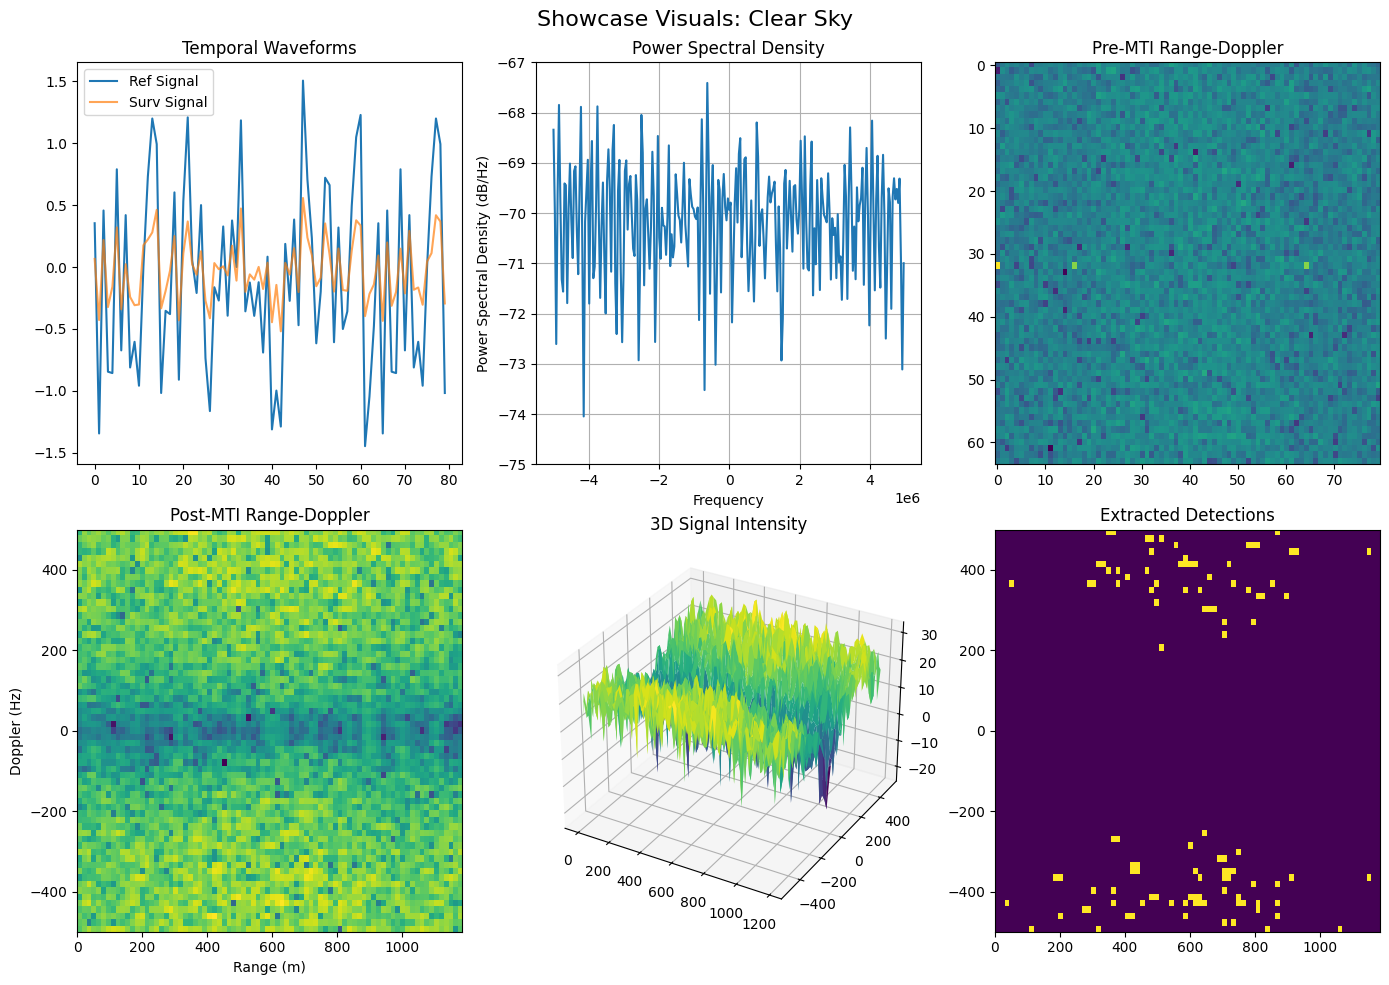


--- Showcase Scenario: Slow Drone ---
CPI Pulses: 64
Max Intensity: 444.71516777548896
Detection Count: 1


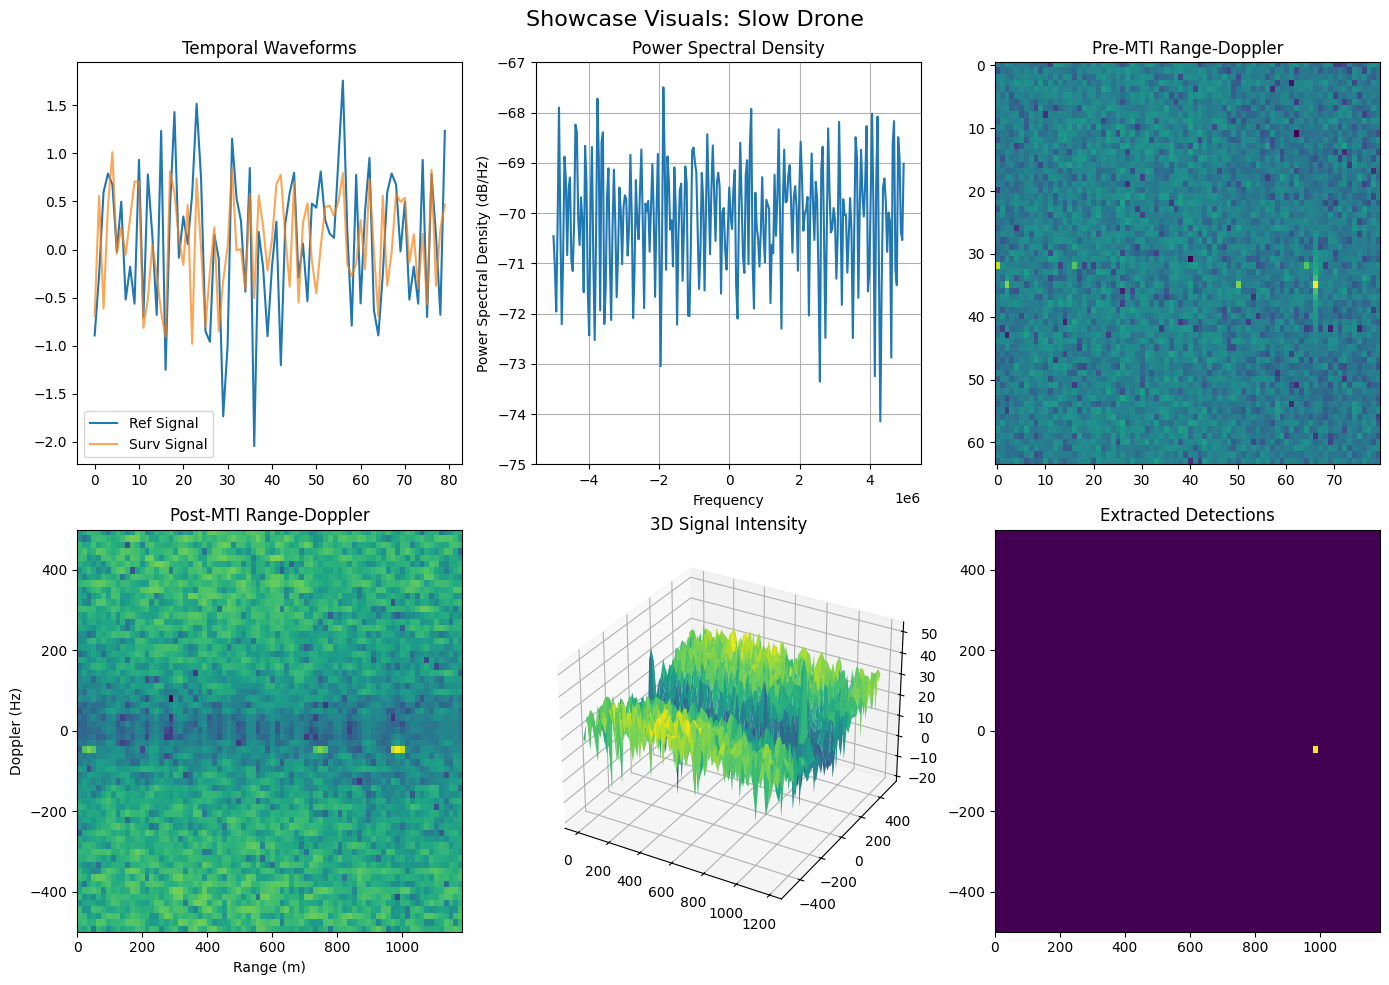


--- Showcase Scenario: Fast Drone ---
CPI Pulses: 64
Max Intensity: 2709.578134698067
Detection Count: 1


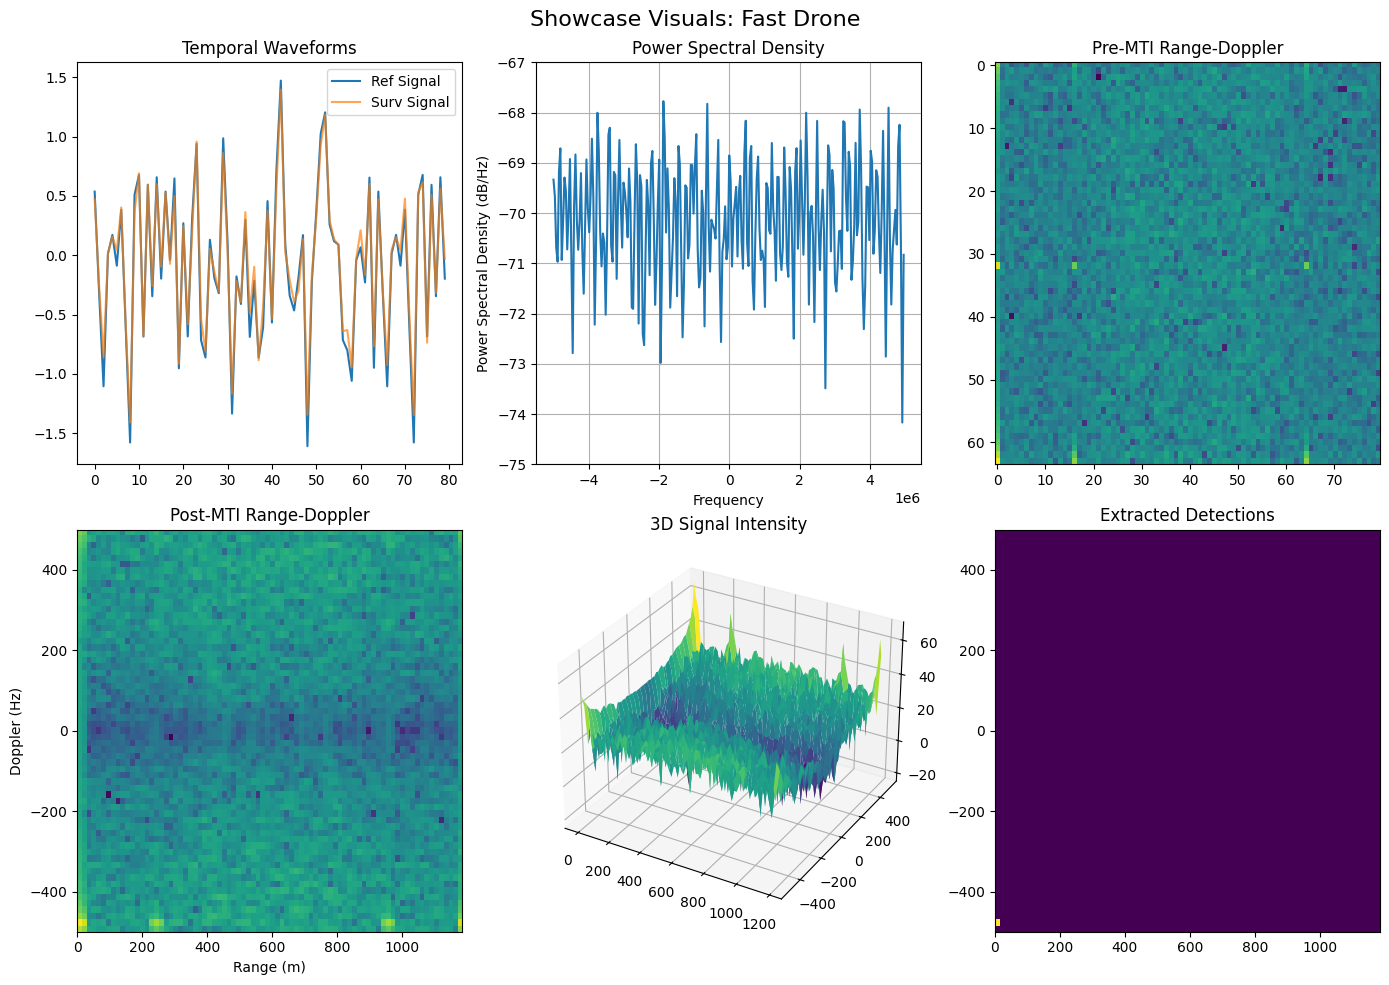


--- Showcase Scenario: Swarm ---
CPI Pulses: 64
Max Intensity: 1339.1029254477528
Detection Count: 3


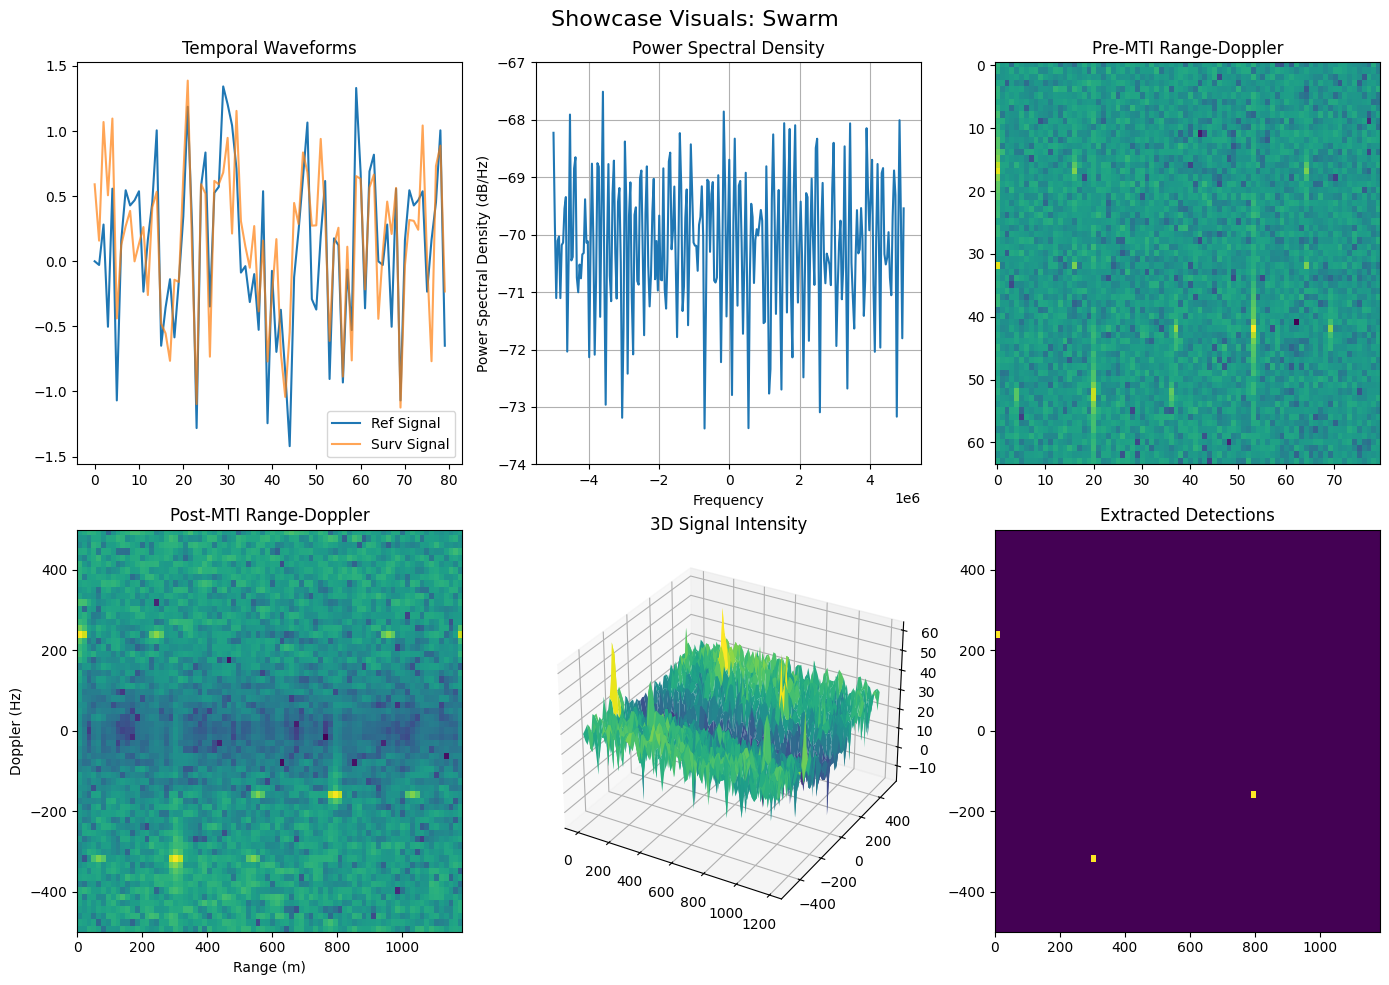

In [8]:
# Demonstrating Baseline (No targets)
run("Clear Sky", [])

# Demonstrating Slow Target Performance
run("Slow Drone", [{"R":1000, "v":3, "amp":0.6}])

# Demonstrating High-Velocity Unambiguous Tracking
run("Fast Drone", [{"R":1200, "v":30, "amp":0.6}])

# Demonstrating Swarm Resolution Capabilities
run("Swarm", [
    {"R":800, "v":10, "amp":0.5},
    {"R":1200, "v":-15, "amp":0.4},
    {"R":1500, "v":20, "amp":0.3}
])